In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize and cast
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f"Original training shape: {x_train.shape}")

/Users/bidhanroy/Desktop/Year3/Sem 6/BDA Lab/venv/lib/python3.13/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Original training shape: (50000, 32, 32, 3)


In [3]:
def create_long_tailed_imbalance(x, y, imbalance_ratio=0.01):
    """
    Creates a long-tailed distribution where class 0 is majority
    and class 9 is extreme minority[cite: 10].
    """
    new_x, new_y = [], []
    num_classes = 10
    for c in range(num_classes):
        indices = np.where(y == c)[0]
        # Calculate samples for this class based on exponential decay
        num_samples = int(len(indices) * (imbalance_ratio ** (c / (num_classes - 1))))
        keep_indices = indices[:num_samples]
        new_x.append(x[keep_indices])
        new_y.append(y[keep_indices])
        print(f"Class {c}: {num_samples} samples")

    return np.concatenate(new_x), np.concatenate(new_y)

x_train_imb, y_train_imb = create_long_tailed_imbalance(x_train, y_train)

Class 0: 5000 samples
Class 1: 2997 samples
Class 2: 1796 samples
Class 3: 1077 samples
Class 4: 645 samples
Class 5: 387 samples
Class 6: 232 samples
Class 7: 139 samples
Class 8: 83 samples
Class 9: 50 samples


In [4]:
def focal_loss(gamma=2.0, alpha=0.25):
    """
    Down-weights easy examples and focuses on hard, misclassified ones.
    """
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), 10)
        y_true = tf.squeeze(y_true, axis=1)
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)

        # Calculate cross entropy
        cross_entropy = -y_true * tf.math.log(y_pred)
        # Calculate weight factor (1 - pt)^gamma
        weight = alpha * tf.pow(1 - y_pred, gamma)

        return tf.reduce_sum(weight * cross_entropy, axis=1)
    return focal_loss_fixed

In [10]:
def build_vgg_functional():
    # Explicitly define the input layer
    inputs = tf.keras.Input(shape=(32, 32, 3))

    # Feature Extraction
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # Classification head
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(10, activation='softmax')(x)

    # Create the model
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

# Re-build and compile
model = build_vgg_functional()
model.compile(optimizer='adam', loss=focal_loss(), metrics=['accuracy'])

# Train (Even if you already trained, you must re-run this for the functional model)
history = model.fit(x_train_imb, y_train_imb, epochs=10,
                    batch_size=64, validation_data=(x_test, y_test))

Epoch 1/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 20s 97ms/step - accuracy: 0.6148 - loss: 0.1982 - val_accuracy: 0.2428 - val_loss: 0.4215
Epoch 2/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 23s 120ms/step - accuracy: 0.7101 - loss: 0.1242 - val_accuracy: 0.3398 - val_loss: 0.3558
Epoch 3/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 18s 93ms/step - accuracy: 0.7583 - loss: 0.0971 - val_accuracy: 0.3350 - val_loss: 0.3795
Epoch 4/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 17s 90ms/step - accuracy: 0.7938 - loss: 0.0777 - val_accuracy: 0.2807 - val_loss: 0.5726
Epoch 5/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 18s 91ms/step - accuracy: 0.8282 - loss: 0.0598 - val_accuracy: 0.4009 - val_loss: 0.3896
Epoch 6/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 14s 74ms/step - accuracy: 0.8604 - loss: 0.0454 - val_accuracy: 0.4175 - val_loss: 0.4330
Epoch 7/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - accuracy: 0.8922 - loss: 0.0331 - val_accuracy: 0.4227 - val_loss: 0.5545
Epoch 8/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - accuracy: 0.9098 - loss: 0.0263 -

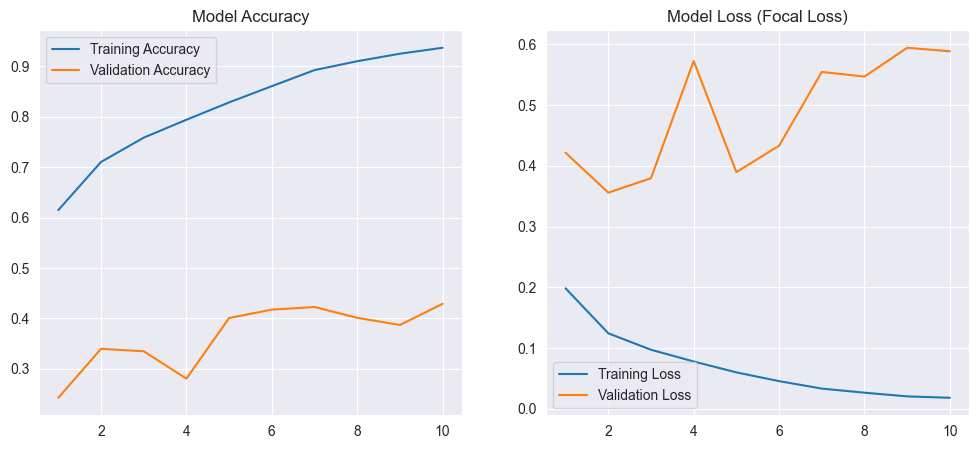

In [11]:
import matplotlib.pyplot as plt

# This will now work because 'history' was created in the previous cell
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Model Loss (Focal Loss)')
plt.legend()

plt.show()

Epoch 1/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 14s 72ms/step - accuracy: 0.9487 - loss: 0.0132 - val_accuracy: 0.4055 - val_loss: 0.6118
Epoch 2/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 17s 90ms/step - accuracy: 0.9585 - loss: 0.0106 - val_accuracy: 0.4083 - val_loss: 0.6645
Epoch 3/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 17s 86ms/step - accuracy: 0.9603 - loss: 0.0106 - val_accuracy: 0.4115 - val_loss: 0.6734
Epoch 4/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 17s 87ms/step - accuracy: 0.9598 - loss: 0.0109 - val_accuracy: 0.4230 - val_loss: 0.7488
Epoch 5/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 17s 89ms/step - accuracy: 0.9562 - loss: 0.0118 - val_accuracy: 0.4109 - val_loss: 0.7141
Epoch 6/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 18s 91ms/step - accuracy: 0.9716 - loss: 0.0071 - val_accuracy: 0.4135 - val_loss: 0.6736
Epoch 7/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 18s 93ms/step - accuracy: 0.9733 - loss: 0.0064 - val_accuracy: 0.3984 - val_loss: 0.7949
Epoch 8/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 17s 90ms/step - accuracy: 0.9663 - loss: 0.0086 - 

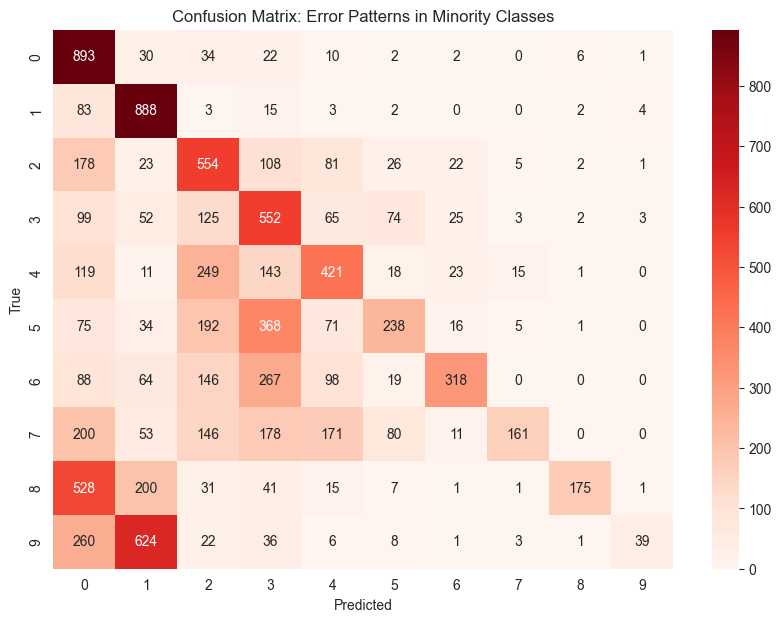

In [14]:
# Training [cite: 28]
history = model.fit(x_train_imb, y_train_imb, epochs=15,
                    batch_size=64, validation_data=(x_test, y_test))

# Predictions for evaluation [cite: 33]
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Report Precision, Recall, and F1 per class [cite: 35]
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix Analysis [cite: 36, 76]
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix: Error Patterns in Minority Classes")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Running t-SNE projection...


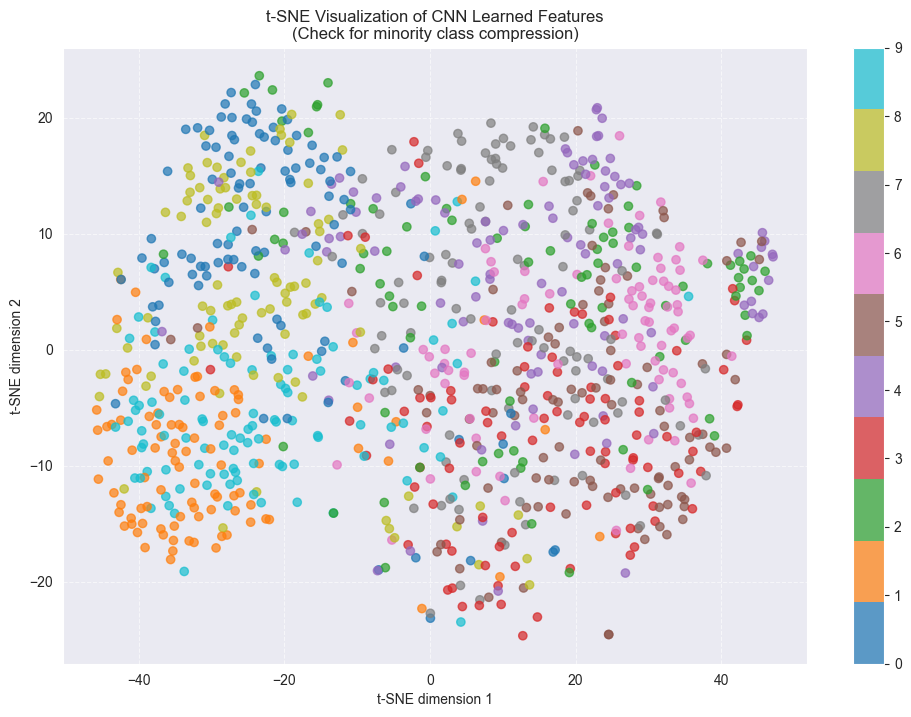

In [15]:
from sklearn.manifold import TSNE
import pandas as pd

def visualize_features(model, x_data, y_data, layer_name=None, num_samples=1000):
    """
    Extracts features from the second-to-last layer and visualizes them using t-SNE.
    """
    # 1. Select a subset of data for faster processing
    indices = np.random.choice(len(x_data), num_samples, replace=False)
    x_subset = x_data[indices]
    y_subset = y_data[indices].flatten()

    # 2. Create a sub-model to extract features from the Dense layer before Softmax
    # If layer_name is None, we take the layer before the final output
    feature_extractor = models.Model(inputs=model.inputs,
                                     outputs=model.layers[-2].output)

    features = feature_extractor.predict(x_subset)

    # 3. Apply t-SNE (Reduces high-dim features to 2D)
    print("Running t-SNE projection...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    tsne_results = tsne.fit_transform(features)

    # 4. Plotting
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1],
                          c=y_subset, cmap='tab10', alpha=0.7)
    plt.colorbar(scatter, ticks=range(10))
    plt.title("t-SNE Visualization of CNN Learned Features\n(Check for minority class compression)")
    plt.xlabel("t-SNE dimension 1")
    plt.ylabel("t-SNE dimension 2")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Run the visualization
visualize_features(model, x_test, y_test)

/Users/bidhanroy/Desktop/Year3/Sem 6/BDA Lab/venv/lib/python3.13/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_11']
Received: inputs=Tensor(shape=(1, 32, 32, 3))
  warnings.warn(msg)


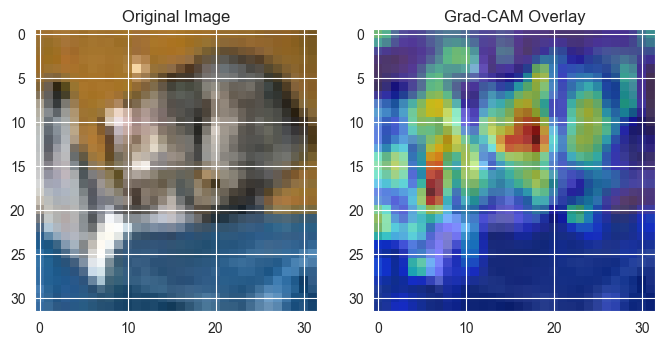

In [16]:
def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    # This model maps input -> (conv_layer_output, final_output)
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Gradients of the class score w.r.t. the conv layer feature map
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the heatmap by the gradient importance
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # ReLU and Normalize
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

# Find the last Conv2D layer automatically
last_conv_name = [l.name for l in model.layers if "conv2d" in l.name][-1]

# Visualizing a sample
sample_idx = 0
img = x_test[sample_idx:sample_idx+1]
heatmap = get_gradcam_heatmap(model, img, last_conv_name)

# Plotting the result
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(x_test[sample_idx])
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(x_test[sample_idx])
plt.imshow(tf.image.resize(heatmap[..., np.newaxis], (32, 32))[:,:,0], alpha=0.5, cmap='jet')
plt.title("Grad-CAM Overlay")
plt.show()